In [2]:
!pip install protobuf==3.20.3

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/soil_image2/soil-type-C5/train"
classes = os.listdir(data_dir)

print(f"Total classes: {len(classes)}")

for cls in classes:
    print(f"Class: {cls}, Number of Image: {len(os.listdir(os.path.join(data_dir, cls)))}")

Total classes: 5
Class: Yellow Soil, Number of Image: 505
Class: Cinder Soil, Number of Image: 565
Class: Peat Soil, Number of Image: 535
Class: Laterite Soil, Number of Image: 521
Class: Black Soil, Number of Image: 2076


In [6]:
from PIL import Image
import os

data_dir = "/content/drive/MyDrive/Colab Notebooks/soil_image2/soil-type-C5/train"
classes = os.listdir(data_dir)

print(f"Total classes: {len(classes)}")

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    images = os.listdir(class_path)

    sizes = set()
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as im:
                sizes.add((im.width, im.height))
        except:
            pass  # ignore corrupted images if any

    print(f"Class: {cls}")
    print(f"  Number of Images: {len(images)}")
    print(f"  Unique Sizes: {sizes}")

Total classes: 5
Class: Yellow Soil
  Number of Images: 505
  Unique Sizes: {(640, 640)}
Class: Cinder Soil
  Number of Images: 565
  Unique Sizes: {(640, 640)}
Class: Peat Soil
  Number of Images: 535
  Unique Sizes: {(640, 640)}
Class: Laterite Soil
  Number of Images: 521
  Unique Sizes: {(640, 640)}
Class: Black Soil
  Number of Images: 2076
  Unique Sizes: {(640, 640)}


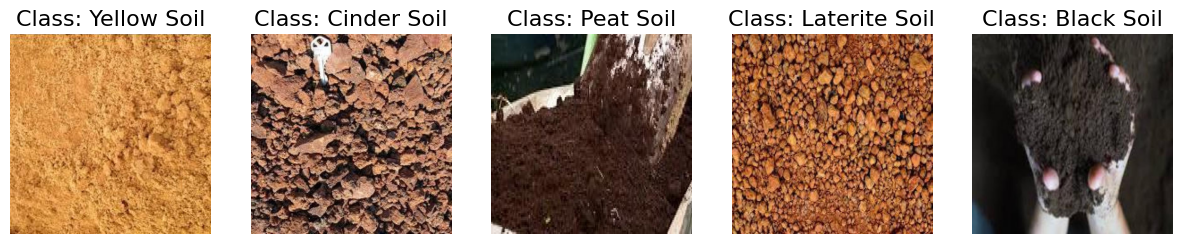

In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(data_dir)

plt.figure(figsize=(15, 5))

for i, cls in enumerate(classes):
    class_path = os.path.join(data_dir, cls)
    images = os.listdir(class_path)

    random_img = random.choice(images)
    img_path = os.path.join(class_path, random_img)

    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}", fontsize=16)
    plt.axis("off")

plt.show()

In [8]:
import os
from PIL import Image, UnidentifiedImageError

deleted = 0

for cls in os.listdir(data_dir):
    class_path = os.path.join(data_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()    # check if image is readable
        except (UnidentifiedImageError, OSError):
            print("Corrupted removed:", img_path)
            os.remove(img_path)
            deleted += 1

print("\nTotal corrupted images removed:", deleted)


Total corrupted images removed: 0


# **Data Augmentation**

In [9]:
from PIL import Image, ImageFilter
from torchvision import datasets, transforms

# Custom filter function
def unsharp_mask(image):
    return image.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3))

# Train Transform (with augmentation)
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(size=224, scale=(0.6, 1.0)),
    transforms.RandomRotation(degrees=25),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.02),
    transforms.Lambda(unsharp_mask),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

# Validation / Test Transform (no augmentation)
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load dataset (original, before splitting)
dataset = datasets.ImageFolder(root=data_dir)

# Count per class
from collections import Counter
class_counts = Counter([label for _, label in dataset])
print("Original class counts:", dict(zip(dataset.classes, [class_counts[i] for i in range(len(dataset.classes))])))


Original class counts: {'Black Soil': 2076, 'Cinder Soil': 565, 'Laterite Soil': 521, 'Peat Soil': 535, 'Yellow Soil': 505}


# **Dataset Split & Weighted Oversampling**

In [10]:
import torch
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import numpy as np

# Shuffle indices
dataset_size = len(dataset)
indices = np.random.permutation(dataset_size)

train_end = int(0.7 * dataset_size)
val_end = int(0.9 * dataset_size)

train_indices = indices[:train_end]
val_indices   = indices[train_end:val_end]
test_indices  = indices[val_end:]

# Create Subsets with separate transforms
train_dataset = Subset(
    datasets.ImageFolder(root=data_dir, transform=transform_train),
    train_indices
)

val_dataset = Subset(
    datasets.ImageFolder(root=data_dir, transform=transform_test),
    val_indices
)

test_dataset = Subset(
    datasets.ImageFolder(root=data_dir, transform=transform_test),
    test_indices
)

# Calculate class weights for training
train_labels = [train_dataset.dataset.targets[i] for i in train_indices]
class_sample_counts = np.array([train_labels.count(c) for c in range(len(dataset.classes))])
class_weights = 1. / class_sample_counts
samples_weights = np.array([class_weights[t] for t in train_labels])
samples_weights = torch.from_numpy(samples_weights).float()

# WeightedRandomSampler for train loader
train_sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

# DataLoaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_dataset)}, Validation size: {len(val_dataset)}, Test size: {len(test_dataset)}")

Train size: 2941, Validation size: 840, Test size: 421


# **Balance Training Dataset Using WeightedRandomSampler**

In [11]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# Get training labels
train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]

# Calculate class counts and weights
num_classes = len(set(train_labels))
class_counts = np.array([train_labels.count(c) for c in range(num_classes)])
class_weights = 1.0 / class_counts  # smaller classes get higher weight
samples_weights = np.array([class_weights[t] for t in train_labels])
samples_weights = torch.from_numpy(samples_weights).float()

# WeightedRandomSampler
train_sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
)

# Update DataLoader for training
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Training DataLoader is balanced with WeightedRandomSampler.")


Training DataLoader is balanced with WeightedRandomSampler.


# **Original vs Balanced Class Distribution on Training Data**

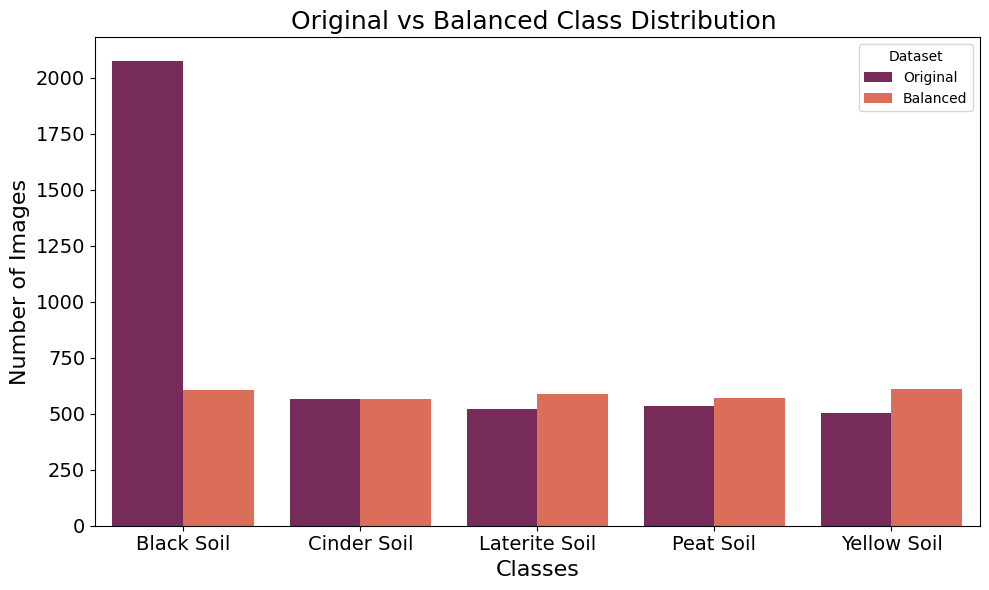

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# riginal class counts
original_labels = [label for _, label in dataset]
original_counts = Counter(original_labels)

# Balanced class counts (simulate one epoch with WeightedRandomSampler)
balanced_labels_epoch = []
for idx in train_sampler:
    # idx is index of sample in train_dataset
    label = train_dataset.dataset.targets[train_dataset.indices[idx]]
    balanced_labels_epoch.append(label)

balanced_counts = Counter(balanced_labels_epoch)

# Create DataFrame for plotting
df_plot = pd.DataFrame({
    'Classes': dataset.classes * 2,
    'Class_Count': [original_counts[i] for i in range(len(dataset.classes))] +
                   [balanced_counts[i] for i in range(len(dataset.classes))],
    'Dataset': ['Original']*len(dataset.classes) + ['Balanced']*len(dataset.classes)
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Classes', y='Class_Count', hue='Dataset', palette='rocket')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Original vs Balanced Class Distribution ", fontsize=18)
plt.xlabel("Classes", fontsize=16)
plt.ylabel("Number of Images", fontsize=16)
plt.tight_layout()
plt.show()


# **Random Soil Images After Augmentation**

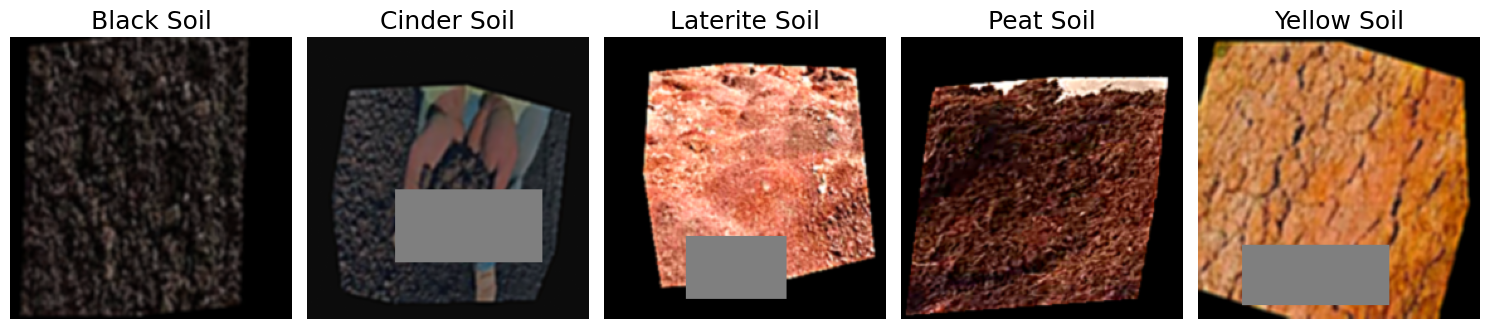

In [14]:
import random
import matplotlib.pyplot as plt
from PIL import Image

num_classes = len(dataset.classes)

# Create a mapping of class index to a list of image paths from the training set
train_image_paths_by_class = {i: [] for i in range(num_classes)}

for idx in train_dataset.indices:
    img_path, label = train_dataset.dataset.samples[idx]
    train_image_paths_by_class[label].append(img_path)

plt.figure(figsize=(15, 5))

for i, cls_name in enumerate(dataset.classes):
    # Get all image paths for this class from the training dataset
    available_paths = train_image_paths_by_class[i]

    if not available_paths:
        print(f"No images found for class: {cls_name} in the training set to display augmented images.")
        continue

    # Pick a random image path from the training set for the current class
    img_path = random.choice(available_paths)
    img = Image.open(img_path).convert("RGB")

    # Apply the train transforms to the image
    img_aug = transform_train(img)

    # Convert tensor to numpy for plotting
    img_np = img_aug.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5) + 0.5

    plt.subplot(1, num_classes, i+1)
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(cls_name, fontsize=18)

plt.tight_layout()
plt.show()

# **Pre_Trained Model**

# **1. Model_ResNet50**

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler
import copy
import numpy as np

# --------------------
# Device
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------------------
# Batch size
# --------------------
batch_size = 32
num_classes = 5

# --------------------
# WeightedRandomSampler
# --------------------
train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]

# force sampler labels into valid range
train_labels = [l if l < num_classes else 0 for l in train_labels]

class_counts = np.array([train_labels.count(c) for c in range(num_classes)])
class_weights = 1.0 / class_counts
samples_weights = np.array([class_weights[t] for t in train_labels])
samples_weights = torch.from_numpy(samples_weights).float()

train_sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
)

# --------------------
# DataLoaders
# --------------------
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --------------------
# Model
# --------------------
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block + FC
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

# Replace FC layer
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# --------------------
# Loss & Optimizer
# --------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

# --------------------
# Training settings
# --------------------
num_epochs = 30
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# --------------------
# Training Loop
# --------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)

        # 🔧 CRITICAL FIX (label safety)
        labels = labels.clone()
        labels[labels < 0] = 0
        labels[labels >= num_classes] = 0
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # --------------------
    # Validation
    # --------------------
    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)

            # 🔧 SAME FIX
            labels = labels.clone()
            labels[labels < 0] = 0
            labels[labels >= num_classes] = 0
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss_total / val_total
    val_acc = 100.0 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_resnet50.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
    )

# --------------------
# Load best model
# --------------------
model.load_state_dict(best_model_wts)

# --------------------
# Test
# --------------------
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # 🔧 SAME FIX
        labels = labels.clone()
        labels[labels < 0] = 0
        labels[labels >= num_classes] = 0
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = 100.0 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")


Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:05<00:00, 19.6MB/s]


Epoch [1/30] Train Loss: 1.0597, Train Acc: 64.03% Val Loss: 0.6198, Val Acc: 77.62%
Epoch [2/30] Train Loss: 0.4396, Train Acc: 84.70% Val Loss: 0.4468, Val Acc: 82.98%
Epoch [3/30] Train Loss: 0.3191, Train Acc: 89.26% Val Loss: 0.2306, Val Acc: 90.36%
Epoch [4/30] Train Loss: 0.2417, Train Acc: 91.36% Val Loss: 0.1615, Val Acc: 95.24%
Epoch [5/30] Train Loss: 0.1921, Train Acc: 93.27% Val Loss: 0.0886, Val Acc: 97.26%
Epoch [6/30] Train Loss: 0.1859, Train Acc: 93.23% Val Loss: 0.1469, Val Acc: 95.48%
Epoch [7/30] Train Loss: 0.1540, Train Acc: 94.53% Val Loss: 0.2276, Val Acc: 92.86%
Epoch [8/30] Train Loss: 0.1469, Train Acc: 94.76% Val Loss: 0.0761, Val Acc: 97.50%
Epoch [9/30] Train Loss: 0.1318, Train Acc: 95.51% Val Loss: 0.0818, Val Acc: 97.38%
Epoch [10/30] Train Loss: 0.1092, Train Acc: 96.29% Val Loss: 0.0825, Val Acc: 97.26%
Epoch [11/30] Train Loss: 0.1170, Train Acc: 96.23% Val Loss: 0.0387, Val Acc: 98.81%
Epoch [12/30] Train Loss: 0.0933, Train Acc: 96.77% Val Loss: 0

# **Training and Validation Accuracy & Loss Curve**

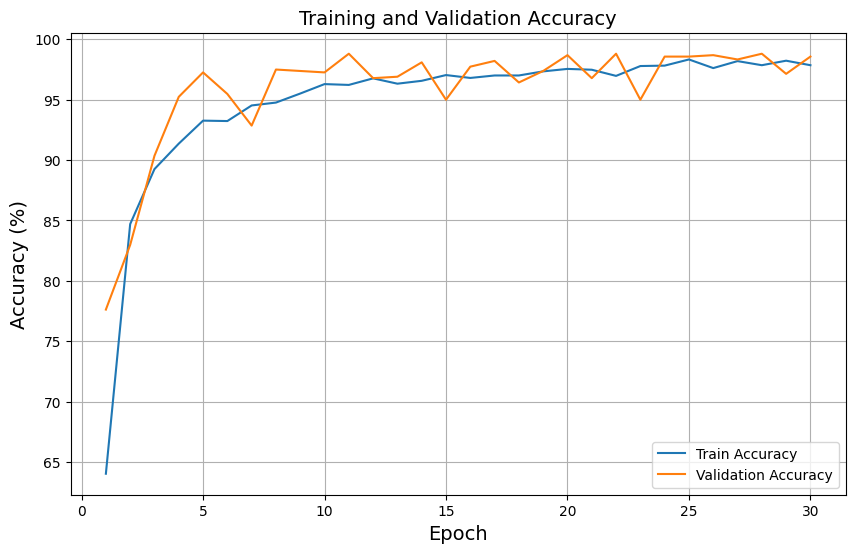

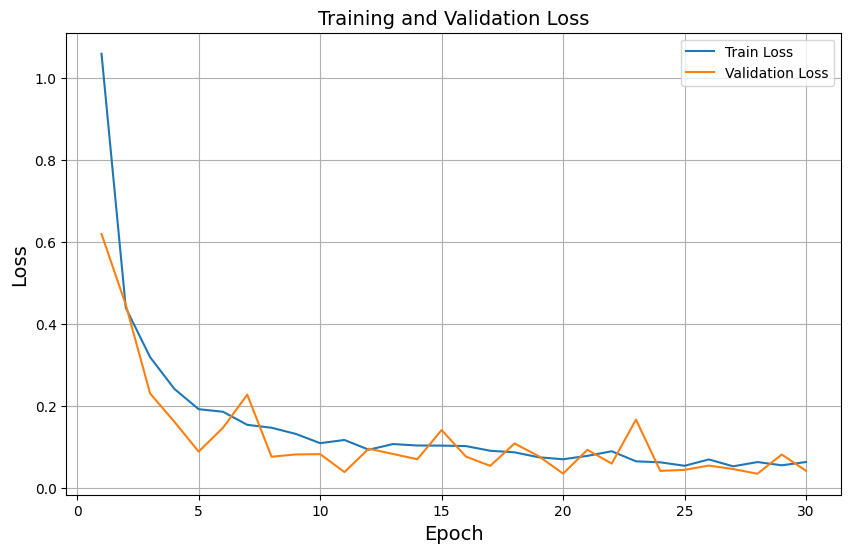

In [16]:
import matplotlib.pyplot as plt
import os

# Create output directory if it doesn't exist
output_dir = "./output"
os.makedirs(output_dir, exist_ok=True)

# Plot Accuracy
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title("Training and Validation Accuracy", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.title("Training and Validation Loss", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# **2. Model_VGG19**

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import vgg19, VGG19_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler
import copy
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Batch size
batch_size = 32

# WeightedRandomSampler for balanced training
train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]
num_classes = len(set(train_labels))
class_counts = np.array([train_labels.count(c) for c in range(num_classes)])
class_weights = 1.0 / class_counts
samples_weights = np.array([class_weights[t] for t in train_labels])
samples_weights = torch.from_numpy(samples_weights).float()
train_sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model
model = vgg19(weights=VGG19_Weights.DEFAULT)


# Freeze early layers (features.0 → features.27)
for param in model.features[:28].parameters():
    param.requires_grad = False

# Unfreeze last convolution block (features.28 → features.35)
for param in model.features[28:].parameters():
    param.requires_grad = True

# Classifier layers are already trainable
for param in model.classifier.parameters():
    param.requires_grad = True
# ------------------------------------------------

# for 5 classes with dropout
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 5)
# dropout
model.classifier = nn.Sequential(
    model.classifier[0],
    model.classifier[1],
    model.classifier[2],
    model.classifier[3],
    model.classifier[4],
    model.classifier[5],
    nn.Dropout(0.5),
    model.classifier[6]
)

model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)

# Training settings
num_epochs = 30
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Training Loop
for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss_total / val_total
    val_acc = 100.0 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_vgg19.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# Load best model
model.load_state_dict(best_model_wts)

# Test Accuracy
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = 100.0 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")


Using device: cuda
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 75.4MB/s]


Epoch [1/30] Train Loss: 0.9024, Train Acc: 63.04% Val Loss: 0.4047, Val Acc: 84.40%
Epoch [2/30] Train Loss: 0.4744, Train Acc: 82.66% Val Loss: 0.4827, Val Acc: 85.83%
Epoch [3/30] Train Loss: 0.4071, Train Acc: 85.58% Val Loss: 0.4425, Val Acc: 84.17%
Epoch [4/30] Train Loss: 0.3453, Train Acc: 87.52% Val Loss: 0.3018, Val Acc: 92.38%
Epoch [5/30] Train Loss: 0.2942, Train Acc: 89.36% Val Loss: 0.6318, Val Acc: 82.86%
Epoch [6/30] Train Loss: 0.2708, Train Acc: 90.75% Val Loss: 0.1380, Val Acc: 95.95%
Epoch [7/30] Train Loss: 0.2650, Train Acc: 90.85% Val Loss: 0.1060, Val Acc: 96.31%
Epoch [8/30] Train Loss: 0.2099, Train Acc: 92.89% Val Loss: 0.1352, Val Acc: 95.95%
Epoch [9/30] Train Loss: 0.2086, Train Acc: 92.62% Val Loss: 0.2511, Val Acc: 93.21%
Epoch [10/30] Train Loss: 0.2235, Train Acc: 92.28% Val Loss: 0.6289, Val Acc: 84.17%
Epoch [11/30] Train Loss: 0.2183, Train Acc: 92.45% Val Loss: 0.6366, Val Acc: 83.33%
Epoch [12/30] Train Loss: 0.1809, Train Acc: 93.40% Val Loss: 0

# **Training and Validation Accuracy & Loss Curve**

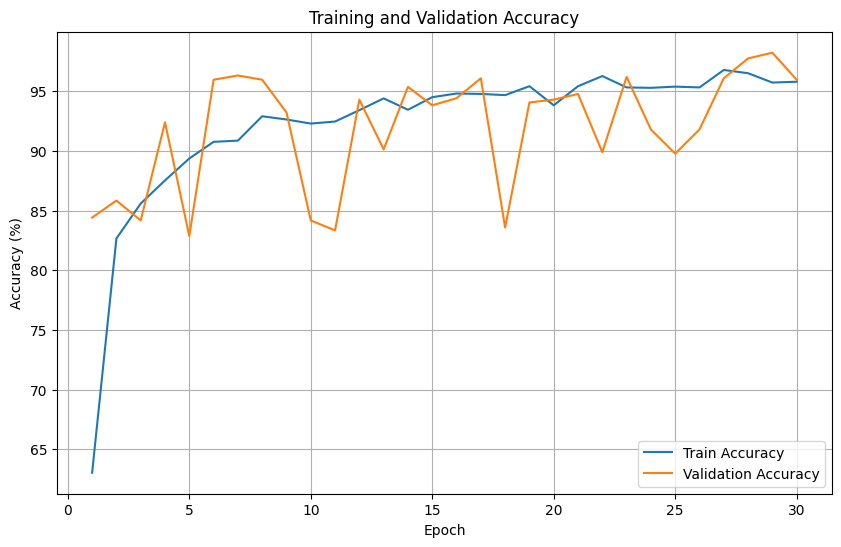

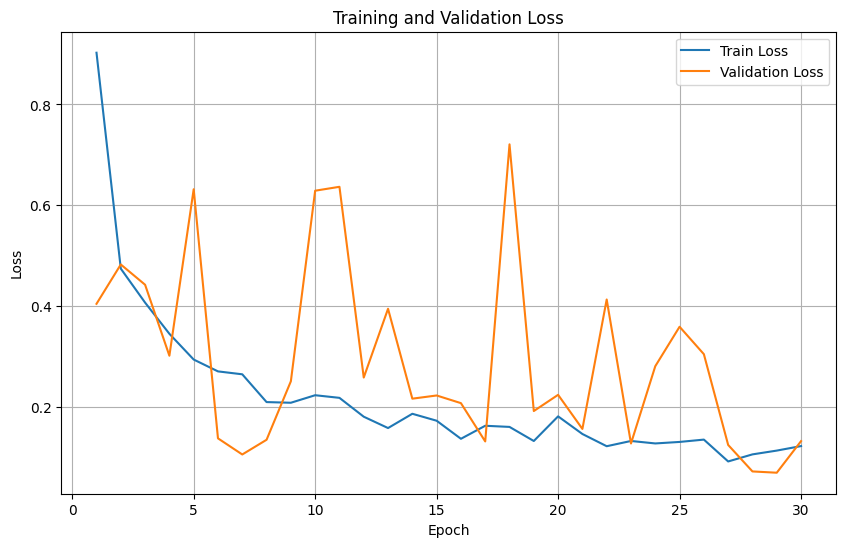

In [18]:
import matplotlib.pyplot as plt
import os

# ----- Create output folder -----
output_dir = "./output"
os.makedirs(output_dir, exist_ok=True)

# ----- Plot Accuracy -----
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
accuracy_plot_path = os.path.join(output_dir, "accuracy_plot.png")
plt.savefig(accuracy_plot_path)
plt.show()

# ----- Plot Loss -----
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# **Custom CNN Models**

# **1. BetterSoilCNN**

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import os

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Hyperparameters
# -------------------------
batch_size = 32
num_epochs = 30
save_path = "best_BetterSoilCNN.pth"

# -------------------------
# WeightedRandomSampler for balanced training
# -------------------------
train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]  # get labels from subset
num_classes = len(set(train_labels))
class_counts = np.array([train_labels.count(c) for c in range(num_classes)])
class_weights = 1.0 / class_counts
samples_weights = np.array([class_weights[t] for t in train_labels])
samples_weights = torch.from_numpy(samples_weights).float()
train_sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

# -------------------------
# DataLoaders
# -------------------------
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train loader uses WeightedRandomSampler with batch size {batch_size}")
print(f"Validation and Test loaders use batch size {batch_size}")

# -------------------------
# Model: BetterSoilCNN
# -------------------------
class BetterSoilCNN(nn.Module):
    def __init__(self, num_classes):
        super(BetterSoilCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout(0.4)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Using device: cuda
Train loader uses WeightedRandomSampler with batch size 32
Validation and Test loaders use batch size 32


In [20]:

# Instantiate model, loss, optimizer, scheduler

num_classes = len(dataset.classes)
model = BetterSoilCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


# Helper functions: train & evaluate (same as your original code)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    epoch_loss = running_loss / total if total else 0.0
    epoch_acc = 100.0 * correct / total if total else 0.0
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    epoch_loss = running_loss / total if total else 0.0
    epoch_acc = 100.0 * correct / total if total else 0.0
    return epoch_loss, epoch_acc, all_preds, all_labels


# Training loop

best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print(f"Training finished. Best val acc: {best_val_acc:.2f}% (saved to {save_path})")

# -------------------------
# Evaluate on test set
# -------------------------
model.load_state_dict(torch.load(save_path))
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")


Epoch [1/30] Train Loss: 0.9881, Train Acc: 61.65% | Val Loss: 0.8320, Val Acc: 75.12%


Epoch [2/30] Train Loss: 0.8642, Train Acc: 68.68% | Val Loss: 0.7381, Val Acc: 70.12%


Epoch [3/30] Train Loss: 0.8303, Train Acc: 69.36% | Val Loss: 0.8098, Val Acc: 74.76%


Epoch [4/30] Train Loss: 0.8366, Train Acc: 68.79% | Val Loss: 0.9083, Val Acc: 62.74%


Epoch [5/30] Train Loss: 0.8337, Train Acc: 68.99% | Val Loss: 0.7201, Val Acc: 72.74%


...

Epoch [27/30] Train Loss: 0.6521, Train Acc: 74.84% | Val Loss: 1.2724, Val Acc: 59.52%


Epoch [28/30] Train Loss: 0.6232, Train Acc: 76.44% | Val Loss: 1.1521, Val Acc: 62.26%


Epoch [29/30] Train Loss: 0.6418, Train Acc: 74.23% | Val Loss: 1.1372, Val Acc: 62.38%


Epoch [30/30] Train Loss: 0.6461, Train Acc: 75.21% | Val Loss: 0.9865, Val Acc: 67.62%
Training finished. Best val acc: 75.24% (saved to best_BetterSoilCNN.pth)


Test Loss: 0.5969, Test Acc: 76.72%


# **Classification Report and Confusion Matrix**

Classification Report:

               precision    recall  f1-score   support

   Black Soil    0.96933   0.75598   0.84946       209
  Cinder Soil    0.69444   0.52083   0.59524        48
Laterite Soil    0.86441   0.89474   0.87931        57
    Peat Soil    0.40909   0.71429   0.52023        63
  Yellow Soil    0.83019   1.00000   0.90722        44

     accuracy                        0.76722       421
    macro avg    0.75349   0.77717   0.75029       421
 weighted avg    0.82540   0.76722   0.78129       421



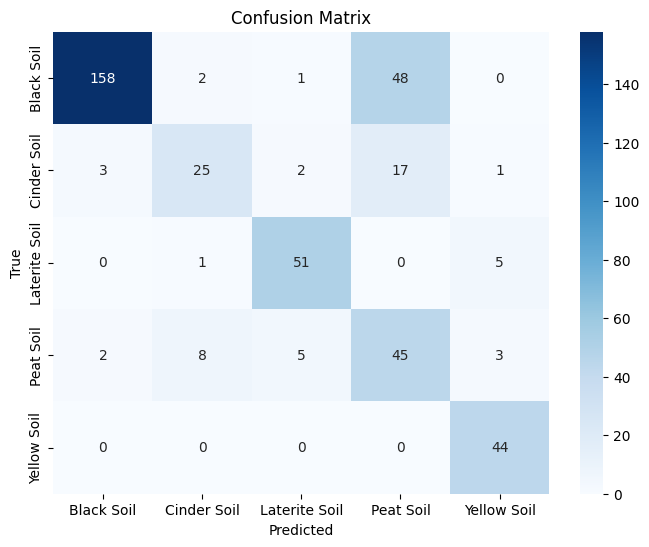

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Classification Report

target_names = dataset.classes

report = classification_report(test_labels, test_preds, target_names=target_names, digits=5)
print("Classification Report:\n")
print(report)


# Confusion Matrix

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# **2. SoilDetectCNN**

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import os

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Hyperparameters
# -------------------------
batch_size = 32
num_epochs = 30
save_path = "best_SoilDetectCNN.pth"

# -------------------------
# WeightedRandomSampler for balanced training
# -------------------------
train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]  # get labels from subset
num_classes = len(set(train_labels))
class_counts = np.array([train_labels.count(c) for c in range(num_classes)])
class_weights = 1.0 / class_counts
samples_weights = np.array([class_weights[t] for t in train_labels])
samples_weights = torch.from_numpy(samples_weights).float()
train_sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

# -------------------------
# DataLoaders
# -------------------------
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train loader uses WeightedRandomSampler with batch size {batch_size}")
print(f"Validation and Test loaders use batch size {batch_size}")

# -------------------------
# Model: SoilDetectCNN
# -------------------------
class SoilDetectCNN(nn.Module):
    def __init__(self, num_classes):
        super(SoilDetectCNN, self).__init__()

        self.features = nn.Sequential(
             # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ELU(inplace=True),  # different activation
            nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ELU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),


            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),  # using normal ReLU here
            nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.4),

            # Block 5
            nn.Conv2d(256, 512, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.5))


        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


Using device: cuda
Train loader uses WeightedRandomSampler with batch size 32
Validation and Test loaders use batch size 32


In [23]:

# Instantiate model, loss, optimizer, scheduler

num_classes = len(dataset.classes)
model = BetterSoilCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


# Helper functions: train & evaluate (same as your original code)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    epoch_loss = running_loss / total if total else 0.0
    epoch_acc = 100.0 * correct / total if total else 0.0
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    epoch_loss = running_loss / total if total else 0.0
    epoch_acc = 100.0 * correct / total if total else 0.0
    return epoch_loss, epoch_acc, all_preds, all_labels


# Training loop

best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print(f"Training finished. Best val acc: {best_val_acc:.2f}% (saved to {save_path})")

# -------------------------
# Evaluate on test set
# -------------------------
model.load_state_dict(torch.load(save_path))
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")


Epoch [1/30] Train Loss: 1.0249, Train Acc: 61.27% | Val Loss: 0.8442, Val Acc: 63.81%


Epoch [2/30] Train Loss: 0.8768, Train Acc: 66.61% | Val Loss: 0.9595, Val Acc: 66.43%


Epoch [3/30] Train Loss: 0.8743, Train Acc: 68.85% | Val Loss: 2.6536, Val Acc: 40.48%


Epoch [4/30] Train Loss: 0.8199, Train Acc: 69.91% | Val Loss: 1.0272, Val Acc: 58.69%


Epoch [5/30] Train Loss: 0.7581, Train Acc: 72.19% | Val Loss: 1.1258, Val Acc: 58.10%


...

Epoch [27/30] Train Loss: 0.6245, Train Acc: 76.20% | Val Loss: 1.0777, Val Acc: 62.86%


Epoch [28/30] Train Loss: 0.6516, Train Acc: 75.28% | Val Loss: 1.0816, Val Acc: 63.57%


Epoch [29/30] Train Loss: 0.6495, Train Acc: 75.82% | Val Loss: 1.0629, Val Acc: 64.29%


Epoch [30/30] Train Loss: 0.6369, Train Acc: 76.10% | Val Loss: 0.9372, Val Acc: 68.69%
Training finished. Best val acc: 70.71% (saved to best_SoilDetectCNN.pth)


Test Loss: 0.7197, Test Acc: 71.73%


# **Classification Report and Confusion Matrix**

Classification Report:

               precision    recall  f1-score   support

   Black Soil    0.96273   0.74163   0.83784       209
  Cinder Soil    0.88235   0.31250   0.46154        48
Laterite Soil    0.78689   0.84211   0.81356        57
    Peat Soil    0.35714   0.63492   0.45714        63
  Yellow Soil    0.62857   1.00000   0.77193        44

     accuracy                        0.71734       421
    macro avg    0.72354   0.70623   0.66840       421
 weighted avg    0.80421   0.71734   0.72779       421



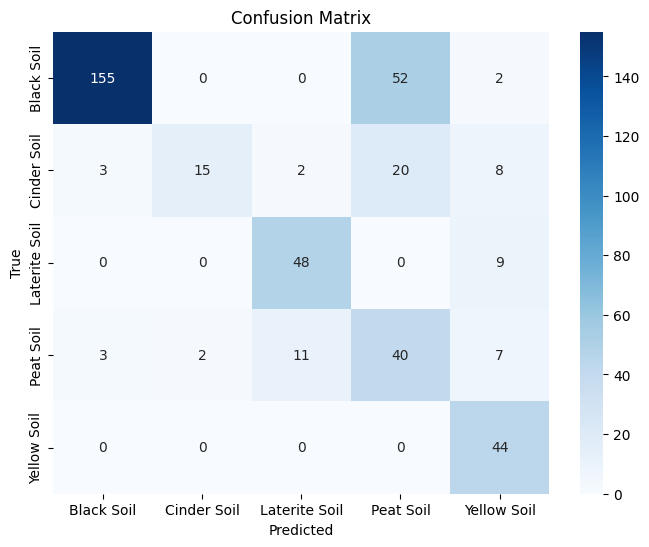

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Classification Report

target_names = dataset.classes

report = classification_report(test_labels, test_preds, target_names=target_names, digits=5)
print("Classification Report:\n")
print(report)


# Confusion Matrix

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
